# 02 · Win probability experiments

**Purpose.** Record the modelling choices behind the served win probability model, with the
evidence for each, so they can be checked and re-run:

1. Which gradient-boosting library? LightGBM vs XGBoost vs CatBoost on identical features.
2. Why a chase dynamic programme feature? The endgame, where data is thinnest.
3. What the model says about one famous match, and why.

The production protocol (tuning, calibration choice, feature selection, backtest) lives in
`criciq_ml.training` and is reported in [`docs/model-cards/win-probability.md`](../docs/model-cards/win-probability.md).
This notebook is exploration: every choice here is made on the **validation seasons**
(2023-2024). The test seasons (2025-2026) appear only as a reference column and were not used to choose.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from criciq_core import paths
from criciq_ml import metrics, registry
from criciq_ml.config import load_config
from criciq_ml.data import load_inputs
from criciq_ml.features import FEATURES, MONOTONE, build_states
from criciq_ml.training import evaluable, trainable

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

cfg = load_config()
states = build_states(load_inputs(paths.warehouse_path()), cfg.feature_config())
labelled = trainable(states)
train = labelled[labelled.season <= cfg.splits.train_through]
valid = labelled[labelled.season.isin(cfg.splits.validation)]
test = evaluable(labelled[labelled.season.isin(cfg.splits.test)])
manifest = registry.load_current().manifest
print(f"{len(states):,} match states · train {len(train):,} · valid {len(valid):,} · test {len(test):,}")

298,037 match states · train 227,313 · valid 35,136 · test 34,604


## 1 · LightGBM, XGBoost or CatBoost?

Each library gets the same features, the same monotonic constraints and comparable capacity
(shallow trees, strong minimum leaf size, learning rate 0.03), with early stopping on validation.
Ties enter as half a win: LightGBM's `cross_entropy` and XGBoost's `binary:logistic` accept soft
labels directly; CatBoost gets ties as two half-weighted rows.

In [2]:
import catboost as cb
import lightgbm as lgb
import xgboost as xgb


def matrices(frame, number):
    return frame[FEATURES[number]].to_numpy(float), frame["label"].to_numpy()


def constraints(number):
    return [MONOTONE[number].get(f, 0) for f in FEATURES[number]]


def fit_lightgbm(number, tr, va):
    params = {
        **{k: v for k, v in cfg.lightgbm.base.items() if k not in {"max_rounds", "early_stopping_rounds"}},
        **{k: v for k, v in manifest["params"][str(number)].items() if k != "recency_half_life"},
        "monotone_constraints": constraints(number), "verbosity": -1, "deterministic": True,
        "force_row_wise": True, "num_threads": 4,
    }
    (x, y), (xv, yv) = matrices(tr, number), matrices(va, number)
    data = lgb.Dataset(x, y)
    booster = lgb.train(params, data, 2000, valid_sets=[data.create_valid(xv, yv)],
                        callbacks=[lgb.early_stopping(100, verbose=False)])
    return lambda f: booster.predict(matrices(f, number)[0], num_iteration=booster.best_iteration)


def fit_xgboost(number, tr, va):
    (x, y), (xv, yv) = matrices(tr, number), matrices(va, number)
    model = xgb.XGBClassifier(
        n_estimators=2000, learning_rate=0.03, max_depth=3, min_child_weight=400,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=5.0, objective="binary:logistic",
        monotone_constraints=tuple(constraints(number)), early_stopping_rounds=100,
        random_state=7, n_jobs=4, tree_method="hist",
    )
    # Soft labels: XGBoost's logistic loss accepts y in [0, 1] through the low-level API.
    dtrain, dvalid = xgb.DMatrix(x, label=y), xgb.DMatrix(xv, label=yv)
    booster = xgb.train(model.get_xgb_params(), dtrain, 2000, evals=[(dvalid, "valid")],
                        early_stopping_rounds=100, verbose_eval=False)
    return lambda f: booster.predict(xgb.DMatrix(matrices(f, number)[0]),
                                     iteration_range=(0, booster.best_iteration + 1))


def fit_catboost(number, tr, va):
    def expand(frame):
        x, y = matrices(frame, number)
        tie = y == 0.5
        xs = np.vstack([x[~tie], x[tie], x[tie]])
        ys = np.concatenate([y[~tie], np.zeros(tie.sum()), np.ones(tie.sum())])
        ws = np.concatenate([np.ones((~tie).sum()), np.full(2 * tie.sum(), 0.5)])
        return cb.Pool(xs, ys, weight=ws)
    model = cb.CatBoostClassifier(
        iterations=2000, learning_rate=0.03, depth=4, l2_leaf_reg=5.0, min_data_in_leaf=400,
        monotone_constraints=constraints(number), od_type="Iter", od_wait=100,
        random_seed=7, verbose=False, thread_count=4, allow_writing_files=False,
    )
    model.fit(expand(tr), eval_set=expand(va), use_best_model=True)
    return lambda f: model.predict_proba(matrices(f, number)[0])[:, 1]


rows = []
for name, fit in {"LightGBM": fit_lightgbm, "XGBoost": fit_xgboost, "CatBoost": fit_catboost}.items():
    for number in (1, 2):
        tr, va, te = (x[x.innings_no == number] for x in (train, valid, test))
        predict = fit(number, tr, va)
        rows.append({
            "library": name, "innings": number,
            "valid log loss": metrics.log_loss(va.label.to_numpy(), predict(va)),
            "test log loss (reference)": metrics.log_loss(te.label.to_numpy(), predict(te)),
        })
libraries = pd.DataFrame(rows)
libraries.pivot(index="library", columns="innings").round(4)

valid log loss         test log loss (reference)        
innings               1       2                         1       2
library                                                          
CatBoost         0.6304  0.4363                    0.6255  0.3732
LightGBM         0.6303  0.4391                    0.6276  0.3753
XGBoost          0.6300  0.4421                    0.6276  0.3728

**Finding:** on the first innings the three libraries are indistinguishable (validation log loss 0.630 each). On the chase CatBoost is ahead by about 0.003 and XGBoost behind by about 0.003, differences far smaller than the season-to-season swings in the backtest (0.05 or more).

**Decision:** keep **LightGBM**. Its TreeSHAP contributions come built in and exact (`pred_contrib`), models save as small reviewable text files, and it supports soft labels and monotonic constraints natively. Switching libraries for a 0.003 gain on one validation split would be tuning to noise.

## 2 · Why a chase dynamic programme?

The last few balls of a chase are the most dramatic moments in a replay and the rarest in the
data: there are only about 1,200 "last ball of a chase" states in IPL history, spread over every
combination of runs needed and wickets. Trees that must not memorise individual matches (large
minimum leaf sizes) cannot resolve them. The WASP-style dynamic programme computes the chance of
a chase exactly for a simplified game, and the model can lean on it where data runs out.

Below, the same chase model is trained with and without that feature and compared on the last two
overs of chases in the validation seasons.

In [3]:
def chase_model(features, tr, va):
    params = {
        **{k: v for k, v in cfg.lightgbm.base.items() if k not in {"max_rounds", "early_stopping_rounds"}},
        **{k: v for k, v in manifest["params"]["2"].items() if k != "recency_half_life"},
        "monotone_constraints": [MONOTONE[2].get(f, 0) for f in features], "verbosity": -1,
        "deterministic": True, "force_row_wise": True, "num_threads": 4,
    }
    data = lgb.Dataset(tr[features].to_numpy(float), tr.label.to_numpy())
    vdata = data.create_valid(va[features].to_numpy(float), va.label.to_numpy())
    booster = lgb.train(params, data, 2000, valid_sets=[vdata], callbacks=[lgb.early_stopping(100, verbose=False)])
    return lambda f: booster.predict(f[features].to_numpy(float), num_iteration=booster.best_iteration)


tr2, va2 = train[train.innings_no == 2], valid[valid.innings_no == 2]
without = [f for f in FEATURES[2] if f != "chase_dp"]
with_dp, without_dp = chase_model(FEATURES[2], tr2, va2), chase_model(without, tr2, va2)
end = evaluable(va2)
end = end[(end.balls_remaining <= 12) & (end.runs_needed > 0)]
pd.DataFrame({
    "valid log loss, last 12 balls": [metrics.log_loss(end.label.to_numpy(), p(end)) for p in (without_dp, with_dp)],
    "valid log loss, whole chase": [metrics.log_loss(evaluable(va2).label.to_numpy(), p(evaluable(va2))) for p in (without_dp, with_dp)],
}, index=["without chase_dp", "with chase_dp"]).round(4)

,"valid log loss, last 12 balls","valid log loss, whole chase"
without chase_dp,0.2407,0.4533
with chase_dp,0.2383,0.4427


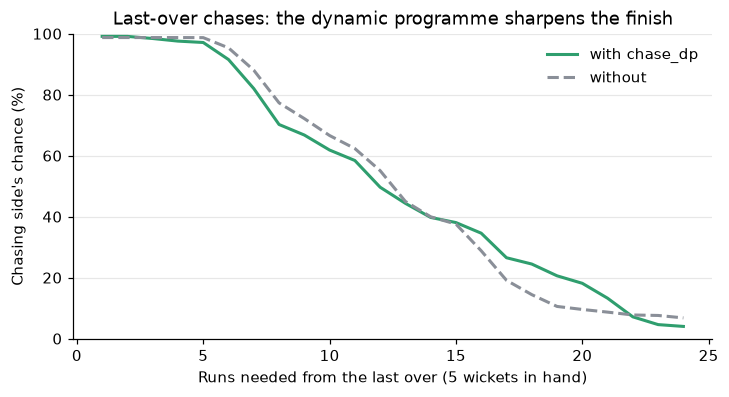

In [4]:
fig, ax = plt.subplots(figsize=(7.5, 3.6))
needed = np.arange(1, 25)
for label, predict, style in (("with chase_dp", with_dp, "-"), ("without", without_dp, "--")):
    grid = pd.DataFrame({
        "legal_balls": 114, "balls_remaining": 6, "runs_needed": needed, "wickets": 5,
        "required_rate": np.minimum(needed, 36.0), "runs_last_12": 18, "wickets_last_12": 1,
    })
    grid["chase_ratio"] = np.log1p(needed) - np.log1p(6)
    grid["required_rate_rel"] = grid.required_rate / (6 * 1.45)
    from criciq_ml import chase
    table = chase.solve({low: chase.PRIOR for low, _ in chase.BUCKETS})
    grid["chase_dp"] = [chase.lookup(table, int(n), 6, 5) for n in needed]
    ax.plot(needed, predict(grid) * 100, style, lw=2, label=label, color="#2f9e6e" if style == "-" else "#8a8f98")
ax.set(xlabel="Runs needed from the last over (5 wickets in hand)", ylabel="Chasing side's chance (%)",
       ylim=(0, 100), title="Last-over chases: the dynamic programme sharpens the finish")
ax.grid(axis="y", alpha=0.3); ax.legend(frameon=False)
plt.show()

**Finding:** the dynamic-programme feature improves validation log loss over the whole chase (0.453 to 0.443) as well as in the last two overs. The curve shows why. Without it, the trees flatten the last over into a few coarse steps and give a side needing 18 from 6 balls about 15%. With it, the model tracks the arithmetic of what one over can deliver.

**Decision:** keep `chase_dp` as a chase feature. It is computed only from earlier seasons' death-over rates, so it adds no leakage.

## 3 · One match, explained: the 2019 final

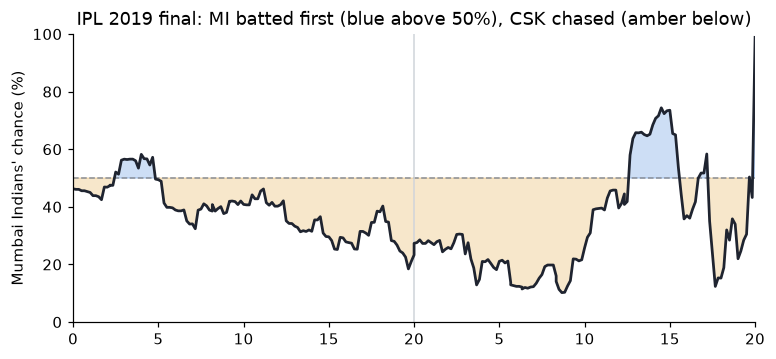

In [5]:
from criciq_ml.features import GROUP_KEYS

model = registry.load_current()
final = states[states.match_id == 1181768].reset_index(drop=True)
scored = model.score(final)
wp_a = np.where(final.innings_no == 1, scored.wp_batting, 1 - scored.wp_batting) * 100
x = (final.innings_no - 1) * 20 + final.legal_balls / 6

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.axhline(50, color="#8a8f98", lw=1, ls="--")
ax.axvline(20, color="#d0d4da", lw=1)
ax.fill_between(x, wp_a, 50, where=wp_a >= 50, color="#3b7dd8", alpha=0.25, interpolate=True)
ax.fill_between(x, wp_a, 50, where=wp_a < 50, color="#e0a030", alpha=0.25, interpolate=True)
ax.plot(x, wp_a, color="#1f2430", lw=1.8)
ax.set(xlim=(0, 40), ylim=(0, 100), ylabel="Mumbai Indians' chance (%)",
       xticks=range(0, 41, 5), xticklabels=[str(t if t <= 20 else t - 20) for t in range(0, 41, 5)],
       title="IPL 2019 final: MI batted first (blue above 50%), CSK chased (amber below)")
plt.show()

In [6]:
chase_rows = final[final.innings_no == 2]
share = scored.loc[chase_rows.index, [f"pts_{k}" for k in GROUP_KEYS]].abs().mean()
(share / share.sum()).rename(lambda c: c.removeprefix("pts_")).round(3).to_frame("share of explanation, CSK chase")

,"share of explanation, CSK chase"
situation,0.757
wickets,0.126
recent,0.117


**Reading the final:** MI were ahead for only a short spell in the first innings. CSK stayed favourites for most of the match until Dhoni's run-out (12.4) flipped it. Watson's 17th-over sixes swung it back, and Malinga's last-ball lbw settled it. Through the chase, three-quarters of the explanation is the chase equation itself (runs needed against balls left). Wickets in hand and the last two overs share the rest. This is the model the replays use.